# 04 — Ensemble From Run History (Stacking)

**职责**: 从 `outputs/run_history.csv` 中为每个模型选出历史最优 run，重建模型后自动挑选一个线性模型和一个树模型做 OOF Stacking。

**流程**: 读取历史记录 → 按模型选最优 run → 重建单模型 → 选择最佳线性/树模型 → OOF Stacking → 保存集成记录

**输入**: `outputs/run_history.csv`, `outputs/models/<run_id>/selected_features.json`, `data/raw/train_data.csv`  
**输出**: `outputs/ensemble_history.csv`, `outputs/figures/ensemble_stacking_*.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from config import DATA_RAW, TARGET, MODEL_DIR, FIG_DIR
from src.preprocessing import load_and_clean, build_feature_matrix
from src.models import discover_models

RUN_HISTORY_PATH = MODEL_DIR.parent / 'run_history.csv'
ENSEMBLE_HISTORY_PATH = MODEL_DIR.parent / 'ensemble_history.csv'

SELECT_BY = 'test_rmse'   # 可改成 'cv_rmse'
ENSEMBLE_NOTES = ''
LINEAR_MODELS = {'lasso', 'elasticnet'}
TREE_MODELS = {'xgboost', 'lightgbm', 'catboost', 'random_forest'}

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. 从历史记录中为每个模型选最优 run

默认按 `SELECT_BY` 指定的指标选择每个模型的历史最优结果。若你担心测试集泄漏，可以把 `SELECT_BY` 改成 `cv_rmse`。

In [2]:
if not RUN_HISTORY_PATH.exists():
    raise FileNotFoundError(f'Run history not found: {RUN_HISTORY_PATH}')

history = pd.read_csv(RUN_HISTORY_PATH)
required_cols = {'run_id', 'model', 'best_params', 'cv_rmse', 'test_rmse'}
missing = required_cols - set(history.columns)
if missing:
    raise ValueError(f'Missing required columns in run_history.csv: {sorted(missing)}')

if SELECT_BY not in {'cv_rmse', 'test_rmse'}:
    raise ValueError("SELECT_BY must be 'cv_rmse' or 'test_rmse'")

history = history.dropna(subset=[SELECT_BY]).copy()

_fallback_features = None
for d in sorted(MODEL_DIR.iterdir(), reverse=True):
    fp = d / 'selected_features.json'
    if d.is_dir() and fp.exists():
        with open(fp) as f:
            _fallback_features = json.load(f)
        print(f'Fallback features from latest run: {d.name} ({len(_fallback_features)} features)')
        break
if _fallback_features is None:
    raise FileNotFoundError('No run directory contains selected_features.json')

history['selected_metric'] = history[SELECT_BY]
history = history.sort_values(['model', 'selected_metric', 'timestamp'])

best_by_model = history.groupby('model', as_index=False).first()
best_by_model = best_by_model.sort_values('selected_metric').reset_index(drop=True)

print(f'\nSelecting best run per model by: {SELECT_BY}')
print(f'Total historical rows: {len(history)}')
print(f'Models selected: {best_by_model["model"].tolist()}')

best_by_model[['model', 'run_id', 'cv_rmse', 'test_rmse', 'n_features', 'selected_metric']]

Fallback features from latest run: 20260322_121844 (25 features)

Selecting best run per model by: test_rmse
Total historical rows: 54
Models selected: ['lightgbm', 'catboost', 'elasticnet', 'lasso', 'xgboost', 'random_forest']


,model,run_id,cv_rmse,test_rmse,n_features,selected_metric
0,lightgbm,20260322_121842,2.1917,1.6842,25,1.6842
1,catboost,20260322_121842,2.2226,1.7674,25,1.7674
2,elasticnet,20260311_004518,1.9883,1.8873,25,1.8873
3,lasso,20260310_231542,1.5485,1.8935,25,1.8935
4,xgboost,20260310_231542,1.5323,1.9262,25,1.9262
5,random_forest,20260319_132032,2.4838,1.9363,25,1.9363


## 2. 重建各模型并做统一对比

这里不会直接依赖历史保存的 `.pkl`，而是读取每条最优记录对应的 `best_params` 和 `selected_features.json`，在当前统一的数据切分上重新训练并评估。这样对比口径更一致。

In [3]:
df = load_and_clean(DATA_RAW)
df = df.sort_values('startdate').reset_index(drop=True)
X_full, y_full, _ = build_feature_matrix(df, TARGET)

split_idx = int(len(X_full) * 0.8)
X_train_full, X_test_full = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]

registry = discover_models()
selected_models = {}
predictions = {}
base_rows = []

for row in best_by_model.itertuples(index=False):
    name = row.model
    run_id = row.run_id
    if name not in registry:
        print(f'Skip unknown model: {name}')
        continue

    run_dir = MODEL_DIR / run_id
    features_path = run_dir / 'selected_features.json'
    if features_path.exists():
        with open(features_path) as f:
            selected_features = json.load(f)
    else:
        selected_features = _fallback_features
        print(f'  [{name}] run {run_id} missing features json, using fallback')

    best_params = {}
    if isinstance(row.best_params, str) and row.best_params.strip():
        best_params = json.loads(row.best_params)

    pipe = registry[name].build_pipeline()
    if best_params:
        pipe.set_params(**best_params)

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    rebuilt_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rebuilt_r2 = r2_score(y_test, y_pred)

    selected_models[name] = {
        'run_id': run_id,
        'pipeline': pipe,
        'features': selected_features,
        'best_params': best_params,
    }
    predictions[name] = y_pred
    base_rows.append({
        'Model': name,
        'Source Run': run_id,
        'CV RMSE (history)': round(row.cv_rmse, 4) if pd.notna(row.cv_rmse) else np.nan,
        'Test RMSE (history)': round(row.test_rmse, 4) if pd.notna(row.test_rmse) else np.nan,
        'Rebuilt Test RMSE': round(rebuilt_rmse, 4),
        'Rebuilt Test R²': round(rebuilt_r2, 4),
        'Features': len(selected_features),
    })

base_results = pd.DataFrame(base_rows).set_index('Model').sort_values('Rebuilt Test RMSE')
print(f'Train: {X_train_full.shape}, Test: {X_test_full.shape}')
print(f'Rebuilt models: {list(base_results.index)}')
base_results

/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  [elasticnet] run 20260311_004518 missing features json, using fallback
  [lasso] run 20260310_231542 missing features json, using fallback
  [xgboost] run 20260310_231542 missing features json, using fallback
Train: (300587, 242), Test: (75147, 242)
Rebuilt models: ['lightgbm', 'catboost', 'elasticnet', 'lasso', 'xgboost', 'random_forest']


,Source Run,CV RMSE (history),Test RMSE (history),Rebuilt Test RMSE,Rebuilt Test R²,Features
Model,,,,,,
lightgbm,20260322_121842,2.1917,1.6842,1.6842,0.9298,25
catboost,20260322_121842,2.2226,1.7674,1.7674,0.9227,25
elasticnet,20260311_004518,1.9883,1.8873,1.8873,0.9118,25
lasso,20260310_231542,1.5485,1.8935,1.8935,0.9113,25
xgboost,20260310_231542,1.5323,1.9262,1.9262,0.9082,25
random_forest,20260319_132032,2.4838,1.9363,1.9363,0.9072,25


## 3. OOF Stacking：最佳线性模型 + 最佳树模型

从重建后的结果里选出最优线性模型和最优树模型，用 `TimeSeriesSplit(5折)` 生成 OOF 预测，训练一个 `LinearRegression` 元模型来学习最优权重与偏差校正。

In [4]:
ranked = base_results.index.tolist()
best_linear = next((name for name in ranked if name in LINEAR_MODELS), None)
best_tree = next((name for name in ranked if name in TREE_MODELS), None)
if not best_linear or not best_tree:
    raise ValueError('Need at least one linear model and one tree model in history')

linear_info = selected_models[best_linear]
tree_info = selected_models[best_tree]
linear_pred = predictions[best_linear]
tree_pred = predictions[best_tree]
linear_rmse = base_results.loc[best_linear, 'Rebuilt Test RMSE']
tree_rmse = base_results.loc[best_tree, 'Rebuilt Test RMSE']

print(f'Best linear: {best_linear} (run={linear_info["run_id"]}, RMSE={linear_rmse})')
print(f'Best tree:   {best_tree} (run={tree_info["run_id"]}, RMSE={tree_rmse})')

tscv = TimeSeriesSplit(n_splits=5)
oof_linear = np.full(len(y_train), np.nan)
oof_tree = np.full(len(y_train), np.nan)

for train_idx, val_idx in tscv.split(X_train_full):
    pl = clone(linear_info['pipeline'])
    X_tr_linear = X_train_full.iloc[train_idx][linear_info['features']]
    X_val_linear = X_train_full.iloc[val_idx][linear_info['features']]
    pl.fit(X_tr_linear, y_train.iloc[train_idx])
    oof_linear[val_idx] = pl.predict(X_val_linear)

    pt = clone(tree_info['pipeline'])
    X_tr_tree = X_train_full.iloc[train_idx][tree_info['features']]
    X_val_tree = X_train_full.iloc[val_idx][tree_info['features']]
    pt.fit(X_tr_tree, y_train.iloc[train_idx])
    oof_tree[val_idx] = pt.predict(X_val_tree)

valid = ~np.isnan(oof_linear) & ~np.isnan(oof_tree)
meta_X_train = np.column_stack([oof_linear[valid], oof_tree[valid]])
meta_X_test = np.column_stack([linear_pred, tree_pred])
meta_model = LinearRegression()
meta_model.fit(meta_X_train, y_train.values[valid])
stack_pred = meta_model.predict(meta_X_test)
ensemble_rmse = float(np.sqrt(mean_squared_error(y_test, stack_pred)))
ensemble_r2 = float(r2_score(y_test, stack_pred))
ensemble_bias = float(np.mean(y_test.values - stack_pred))

print(f'\n[Stacking] coef={np.round(meta_model.coef_, 4)}, '
      f'intercept={meta_model.intercept_:.4f}, bias={ensemble_bias:.4f}')

comparison_df = pd.DataFrame([
    {'Model': best_linear, 'Type': 'Linear', 'RMSE': linear_rmse,
     'R²': float(base_results.loc[best_linear, 'Rebuilt Test R²'])},
    {'Model': best_tree, 'Type': 'Tree', 'RMSE': tree_rmse,
     'R²': float(base_results.loc[best_tree, 'Rebuilt Test R²'])},
    {'Model': 'Stacking', 'Type': 'Ensemble', 'RMSE': ensemble_rmse, 'R²': ensemble_r2},
]).sort_values('RMSE').reset_index(drop=True)

print('\nComparison:')
comparison_df

Best linear: elasticnet (run=20260311_004518, RMSE=1.8873)
Best tree:   lightgbm (run=20260322_121842, RMSE=1.6842)


/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



[Stacking] coef=[0.6898 0.2514], intercept=0.9447, bias=-0.3931

Comparison:


/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,Type,RMSE,R²
0,Stacking,Ensemble,1.647044,0.932857
1,lightgbm,Tree,1.684200,0.929800
2,elasticnet,Linear,1.887300,0.911800


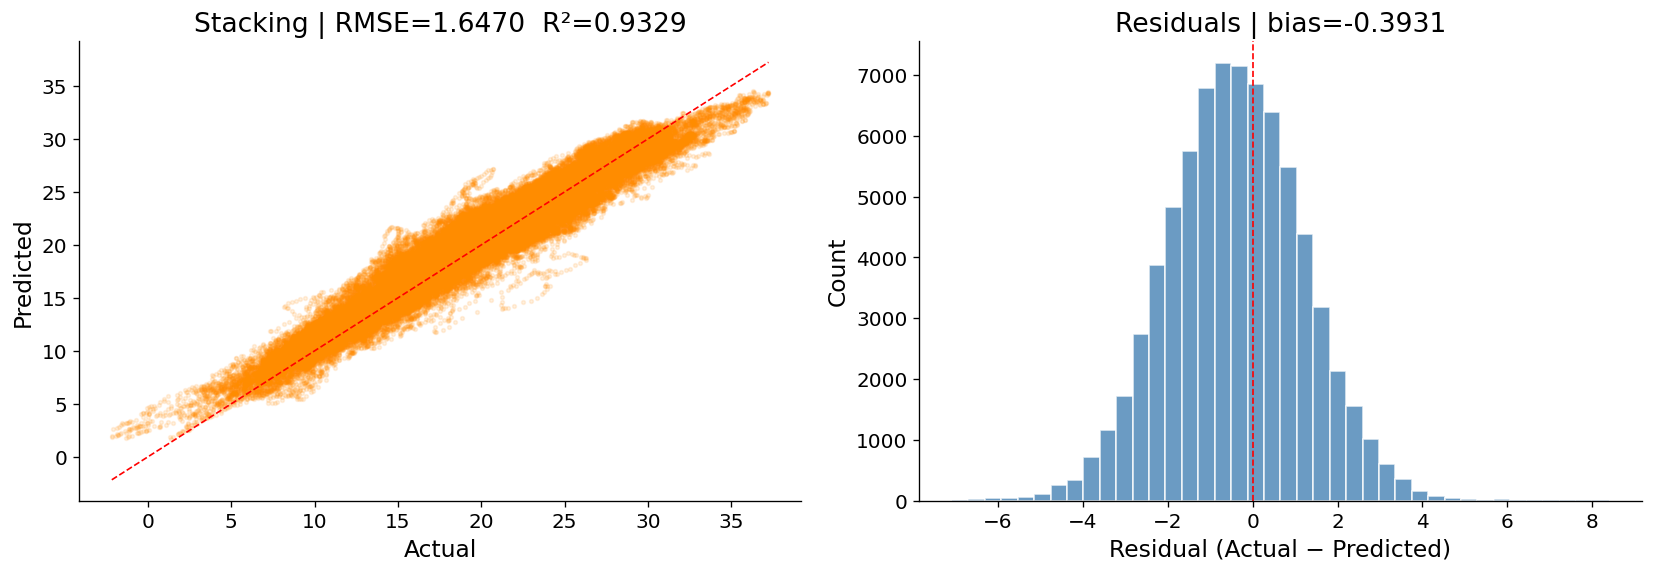

Saved figure -> /Users/zhangjiayu/PythonProject/weather-forecast/outputs/figures/ensemble_stacking_20260322_122041.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y_test, stack_pred, s=5, alpha=0.12, color='darkorange')
lims = [float(min(y_test.min(), stack_pred.min())), float(max(y_test.max(), stack_pred.max()))]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Stacking | RMSE={ensemble_rmse:.4f}  R²={ensemble_r2:.4f}')

residuals = y_test.values - stack_pred
ax = axes[1]
ax.hist(residuals, bins=40, edgecolor='white', color='steelblue', alpha=0.8)
ax.axvline(0, ls='--', color='red', lw=1)
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title(f'Residuals | bias={ensemble_bias:.4f}')

FIG_DIR.mkdir(parents=True, exist_ok=True)
ensemble_run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_name = f'ensemble_stacking_{ensemble_run_id}.png'
fig_path = FIG_DIR / fig_name
plt.tight_layout()
plt.savefig(fig_path, bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved figure -> {fig_path}')

## 4. 保存 ensemble 结果

将本次 Stacking 的配置和指标追加到 `outputs/ensemble_history.csv`。

In [6]:
record = {
    'ensemble_run_id': ensemble_run_id,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'select_by': SELECT_BY,
    'best_linear': best_linear,
    'linear_run_id': linear_info['run_id'],
    'linear_rmse': round(linear_rmse, 4),
    'best_tree': best_tree,
    'tree_run_id': tree_info['run_id'],
    'tree_rmse': round(tree_rmse, 4),
    'stacking_rmse': round(ensemble_rmse, 4),
    'stacking_r2': round(ensemble_r2, 4),
    'stacking_coef_linear': round(float(meta_model.coef_[0]), 4),
    'stacking_coef_tree': round(float(meta_model.coef_[1]), 4),
    'stacking_intercept': round(float(meta_model.intercept_), 4),
    'stacking_bias': round(ensemble_bias, 4),
    'figure_path': f'outputs/figures/{fig_name}',
    'notes': ENSEMBLE_NOTES,
}

new_row = pd.DataFrame([record])
if ENSEMBLE_HISTORY_PATH.exists():
    ensemble_history = pd.concat([pd.read_csv(ENSEMBLE_HISTORY_PATH), new_row], ignore_index=True)
else:
    ensemble_history = new_row
ensemble_history.to_csv(ENSEMBLE_HISTORY_PATH, index=False)

print(f'Saved ensemble history -> {ENSEMBLE_HISTORY_PATH}')
print(f'Stacking RMSE={ensemble_rmse:.4f}, R²={ensemble_r2:.4f}')
ensemble_history.tail()

Saved ensemble history -> /Users/zhangjiayu/PythonProject/weather-forecast/outputs/ensemble_history.csv
Stacking RMSE=1.6470, R²=0.9329


,ensemble_run_id,timestamp,select_by,best_linear,linear_run_id,linear_rmse,best_tree,tree_run_id,tree_rmse,blending_rmse,...,ensemble_rmse,ensemble_r2,best_weight_linear,stacking_coef_linear,stacking_coef_tree,stacking_intercept,stacking_bias,figure_path,notes,stacking_r2
0,20260319_122203,2026-03-19 12:22:03,test_rmse,elasticnet,20260319_121319,1.8873,random_forest,20260319_121319,1.9497,1.7218,...,1.7218,0.9266,0.55,0.8258,0.1107,1.1104,-0.4273,/Users/zhangjiayu/PythonProject/weather-foreca...,NaN,NaN
1,20260319_122521,2026-03-19 12:25:22,test_rmse,elasticnet,20260311_004518,1.8873,catboost,20260310_231542,1.9025,1.6744,...,1.6109,0.9358,0.50,0.6536,0.2855,0.8727,-0.3560,/Users/zhangjiayu/PythonProject/weather-foreca...,NaN,NaN
2,20260319_132306,2026-03-19 13:23:07,test_rmse,elasticnet,20260311_004518,1.8873,catboost,20260310_231542,1.9025,NaN,...,NaN,NaN,NaN,0.6536,0.2855,0.8727,-0.3560,outputs/figures/ensemble_stacking_20260319_132...,NaN,0.9358
3,20260322_122041,2026-03-22 12:20:41,test_rmse,elasticnet,20260311_004518,1.8873,lightgbm,20260322_121842,1.6842,NaN,...,NaN,NaN,NaN,0.6898,0.2514,0.9447,-0.3931,outputs/figures/ensemble_stacking_20260322_122...,,0.9329
